In [88]:
# Auto MPG - Regresion multiple + Streamlit en Jupyter (metricas)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8')


In [89]:
# Cargar dataset Auto MPG y preparar datos

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name',
]

auto = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    comment='\t',
    sep=' ',
    skipinitialspace=True,
)

# Nos quedamos con columnas numericas relevantes y eliminamos NaN
auto = auto[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']].dropna()

# Conversion a metricas
auto['weight_kg'] = auto['weight'] * 0.45359237
auto['consumo_l_100km'] = 235.214583 / auto['mpg']

auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,weight_kg,consumo_l_100km
0,18.0,8,307.0,130.0,3504.0,12.0,70,1589.387664,13.067477
1,15.0,8,350.0,165.0,3693.0,11.5,70,1675.116622,15.680972
2,18.0,8,318.0,150.0,3436.0,11.0,70,1558.543383,13.067477
3,16.0,8,304.0,150.0,3433.0,12.0,70,1557.182606,14.700911
4,17.0,8,302.0,140.0,3449.0,10.5,70,1564.440084,13.836152


In [90]:
# Definir variables para regresion multiple

X = auto[['weight_kg', 'horsepower', 'cylinders']]
y = auto['consumo_l_100km']

X.head()


,weight_kg,horsepower,cylinders
0,1589.387664,130.0,8
1,1675.116622,165.0,8
2,1558.543383,150.0,8
3,1557.182606,150.0,8
4,1564.440084,140.0,8


In [91]:
# Separar en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

X_train.shape, X_test.shape


((313, 3), (79, 3))

In [92]:
# Entrenar modelo de regresion multiple

lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)

coeficientes = pd.Series(lin_reg_multi.coef_, index=X.columns)
intercepto = lin_reg_multi.intercept_

print('Intercepto:', round(intercepto, 3))
print('Coeficientes:')
print(coeficientes.round(6))


Intercepto: -0.751
Coeficientes:
weight_kg     0.004878
horsepower    0.033263
cylinders     0.342169
dtype: float64


In [93]:
# Evaluar el modelo multiple

y_pred = lin_reg_multi.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2  (coeficiente de determinacion): {r2:.4f}')
print(f'MAE (error absoluto medio)       : {mae:.4f} L/100km')


R2  (coeficiente de determinacion): 0.8389
MAE (error absoluto medio)       : 1.1914 L/100km


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



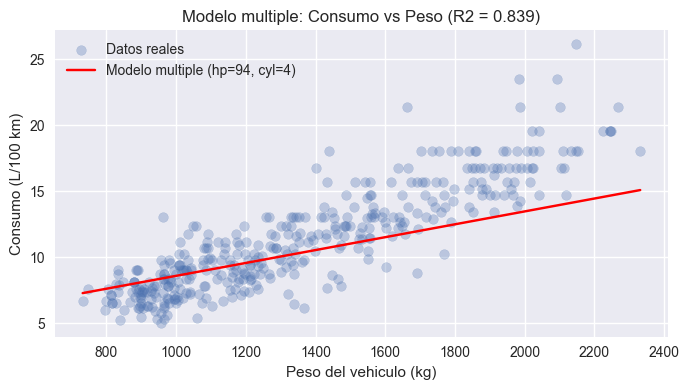

In [94]:
# Grafico fijo: peso vs consumo con linea del modelo multiple

min_peso = auto['weight_kg'].min()
max_peso = auto['weight_kg'].max()
hp_fijo = auto['horsepower'].median()
cil_fijo = auto['cylinders'].mode()[0]

pesos_linea = np.linspace(min_peso, max_peso, 100)
X_linea = np.column_stack([
    pesos_linea,
    np.full_like(pesos_linea, hp_fijo),
    np.full_like(pesos_linea, cil_fijo),
])
consumos_linea = lin_reg_multi.predict(X_linea)

plt.figure(figsize=(7, 4))
plt.scatter(auto['weight_kg'], auto['consumo_l_100km'], alpha=0.3, label='Datos reales')
plt.plot(pesos_linea, consumos_linea, color='red', label=f'Modelo multiple (hp={hp_fijo:.0f}, cyl={cil_fijo})')
plt.xlabel('Peso del vehiculo (kg)')
plt.ylabel('Consumo (L/100 km)')
plt.title(f'Modelo multiple: Consumo vs Peso (R2 = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()
